## EDA первых 10-ти признаков **campaigns.csv**

In [25]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [ ]:
df_campaigns = pd.read_csv('campaigns.csv')
df_campaigns.head()

,id,campaign_type,channel,topic,started_at,finished_at,total_count,ab_test,warmup_mode,hour_limit,subject_length,subject_with_personalization,subject_with_deadline,subject_with_emoji,subject_with_bonuses,subject_with_discount,subject_with_saleout,is_test,position
0,63,bulk,mobile_push,sale out,2021-04-30 07:22:36.615023,2021-04-30 07:23:41,48211.0,NaN,False,NaN,146.0,False,False,True,False,False,False,NaN,NaN
1,64,bulk,mobile_push,sale out,2021-04-30 09:02:50.817227,2021-04-30 09:04:08,1037337.0,NaN,False,NaN,97.0,False,False,True,False,False,False,NaN,NaN
2,78,bulk,mobile_push,sale out,2021-05-06 07:14:10.533318,2021-05-06 07:15:17,70080.0,NaN,False,NaN,146.0,False,False,True,False,False,False,NaN,NaN
3,79,bulk,mobile_push,sale out,2021-05-06 09:03:56.486750,2021-05-06 09:42:15,921838.0,NaN,False,NaN,97.0,False,False,True,False,False,False,NaN,NaN
4,89,bulk,mobile_push,NaN,2021-05-07 11:54:06.168664,2021-05-07 11:54:38,45503.0,NaN,False,NaN,109.0,False,True,True,False,False,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1902,179,transactional,email,profile updated,NaN,NaN,NaN,NaN,NaN,NaN,134.0,False,False,False,False,False,False,NaN,NaN
1903,35,transactional,email,order reminder,NaN,NaN,NaN,NaN,NaN,NaN,88.0,False,False,False,False,False,False,NaN,NaN
1904,57,transactional,email,order reminder,NaN,NaN,NaN,NaN,NaN,NaN,88.0,False,False,False,False,False,False,NaN,NaN
1905,56,transactional,email,order reminder,NaN,NaN,NaN,NaN,NaN,NaN,88.0,False,False,False,False,False,False,NaN,NaN


In [ ]:
for col in df_campaigns.columns:
    print(f'\n{col}:')
    print(df_campaigns[col].unique())


id:
[ 63  64  78 ...  57  56 237]

campaign_type:
['bulk' 'trigger' 'transactional']

channel:
['mobile_push' 'email' 'multichannel' 'sms']

topic:
['sale out' nan 'event' 'offer after purchase' 'happy birthday'
 'leave review' 'welcome campaign' 'abandoned cart' 'abandoned category'
 'abandoned view' 'added to wish list' 'abandoned search' 'subscribed'
 'removed from wish list' 'double opt in' 'user added to segment'
 'recent purchase' 'price drop' 'back in stock' 'order shipped'
 'order reminder' 'welcome letter' 'order ready for pickup'
 'order created' 'bonuses expired' 'order cancelled'
 'order pickup still pending' 'profile updated' 'wish list status']

started_at:
['2021-04-30 07:22:36.615023' '2021-04-30 09:02:50.817227'
 '2021-05-06 07:14:10.533318' ... '2023-04-21 09:00:14.149364'
 '2023-04-21 14:49:31.835109' '2023-04-21 15:30:14.136724']

finished_at:
['2021-04-30 07:23:41' '2021-04-30 09:04:08' '2021-05-06 07:15:17' ...
 '2023-04-21 09:01:10' '2023-04-21 14:49:54' '2023-0

## **Значения:**

**campaign_type** - тип кампании
*   bulk - массовая
*   trigger- автоматическая
*   transactional - транзакция (связана с действиями пользователя)

**channel** - Канал коммуникации


**topic** - Значение кампании (тема)

**started_at, finished_at** - Дата и время начала/завершения массовой кампании

**total_count** - Общее количество получателей в массовой кампании

**ab_test** - Массовая кампания в тестовом режиме A/B

**warmup_mode** - Массовая кампания в режиме разогрева

**hour_limit** - Ограничение на час для массовой кампании в режиме разогрева

**subject_length** - Длина темы сообщения














Для начала рассмотрим кол-во пропусков в каждом столбце

In [ ]:
df_campaigns.isna().sum()

id                                 0
campaign_type                      0
channel                            0
topic                             30
started_at                        83
finished_at                       99
total_count                       83
ab_test                         1895
warmup_mode                       77
hour_limit                      1876
subject_length                    27
subject_with_personalization      27
subject_with_deadline             27
subject_with_emoji                27
subject_with_bonuses              27
subject_with_discount             27
subject_with_saleout              27
is_test                         1880
position                        1883
dtype: int64

In [ ]:
df_campaigns.shape

(1907, 19)

Рассмтариваю я признаки до subject_length(включительно)

В нашем датасете всего 1907 строк. Видим, что у 2-х признаков почти все значения - пропуски:


*   ab_test - 1895
*   hour_limit - 1876

Соответственно эти признаки не несут в себе пости никакой информации, рассматривать их в работе не стоит.

## **Вывод:** ab_test и hour_limit -неиформативные признаки

Теперь рассмотрим дубликаты по id (по идентификатору кампании)

In [ ]:
df_campaigns['id'].duplicated().sum()

np.int64(7)

In [ ]:
df_campaigns['id'].value_counts()[df_campaigns['id'].value_counts() > 1]

id
373    2
374    2
381    2
64     2
366    2
368    2
372    2
Name: count, dtype: int64

Видим, что 7 идентификаторов встречаются дважды, рассмотрим их подробнее

In [ ]:
df_campaigns[df_campaigns['id'].duplicated(keep=False)]

,id,campaign_type,channel,topic,started_at,finished_at,total_count,ab_test,warmup_mode,hour_limit,subject_length,subject_with_personalization,subject_with_deadline,subject_with_emoji,subject_with_bonuses,subject_with_discount,subject_with_saleout,is_test,position
1,64,bulk,mobile_push,sale out,2021-04-30 09:02:50.817227,2021-04-30 09:04:08,1037337.0,NaN,False,NaN,97.0,False,False,True,False,False,False,NaN,NaN
34,366,bulk,email,sale out,2021-06-10 08:28:34.471796,2021-06-10 10:19:05,160689.0,NaN,False,NaN,85.0,False,False,True,False,False,False,NaN,NaN
35,368,bulk,mobile_push,sale out,2021-06-11 10:00:11.717483,2021-06-11 10:00:22,16027.0,NaN,False,NaN,117.0,False,False,True,False,False,False,NaN,NaN
36,372,bulk,mobile_push,sale out,2021-06-10 13:00:10.520899,2021-06-10 13:00:21,24425.0,NaN,False,NaN,119.0,False,False,True,False,True,False,NaN,NaN
37,373,bulk,mobile_push,sale out,2021-06-11 14:00:11.427774,2021-06-14 06:00:54,2532.0,NaN,False,NaN,111.0,False,False,True,False,False,False,NaN,NaN
38,374,bulk,email,sale out,2021-06-09 14:15:49.003420,2021-06-09 14:15:59,3.0,NaN,False,NaN,85.0,False,False,True,False,False,False,NaN,NaN
41,381,bulk,email,sale out,2021-06-10 08:10:36.944182,2021-06-10 08:10:48,3.0,NaN,False,NaN,85.0,False,False,True,False,False,False,NaN,NaN
1860,366,transactional,mobile_push,order reminder,NaN,NaN,NaN,NaN,NaN,NaN,125.0,False,False,False,False,False,False,NaN,NaN
1867,64,transactional,email,order ready for pickup,NaN,NaN,NaN,NaN,NaN,NaN,139.0,False,False,False,False,False,False,NaN,NaN
1881,368,transactional,mobile_push,order created,NaN,NaN,NaN,NaN,NaN,NaN,111.0,False,False,False,False,False,False,NaN,NaN


Видим, что каждый дубликат по id отличается по campaign_type

Т.е. у каждой пары одинаковых идентификаторов разный тип кампании.

В некоторых контекстах кампания может одновременно иметь типы bulk и transactional, так что ошибки в данных нет.

### Рассмотрим категориальные признаки:

In [45]:
cat_cols = [
    'campaign_type',
    'channel',
    'topic',
]

In [ ]:
for col in cat_cols:
    print(f'\n=== {col} ===')
    print(df_campaigns[col].value_counts(dropna=False))


=== campaign_type ===
campaign_type
bulk             1830
transactional      50
trigger            27
Name: count, dtype: int64

=== channel ===
channel
mobile_push     1396
email            483
multichannel      27
sms                1
Name: count, dtype: int64

=== topic ===
topic
sale out                      779
happy birthday                332
offer after purchase          316
leave review                  287
event                          63
NaN                            30
welcome campaign               27
order ready for pickup         10
order shipped                  10
order created                  10
order reminder                  9
abandoned cart                  6
order pickup still pending      4
abandoned view                  3
abandoned search                2
added to wish list              2
abandoned category              2
subscribed                      2
order cancelled                 2
price drop                      2
removed from wish list          1
b

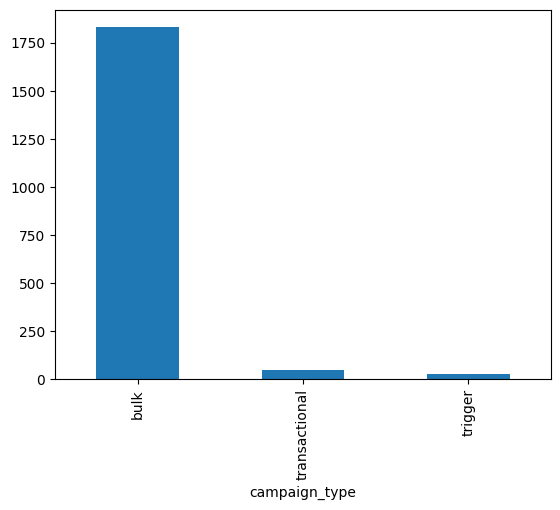

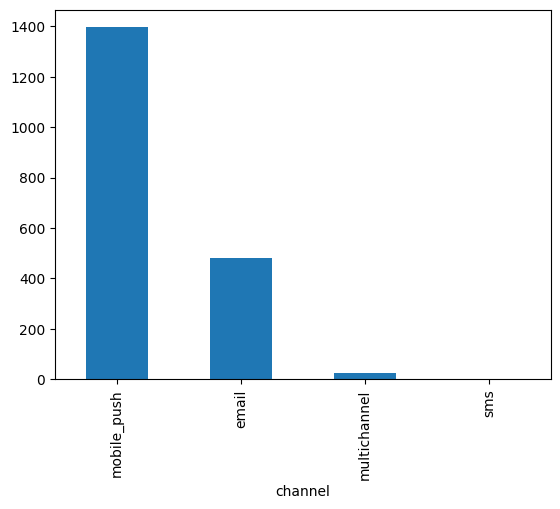

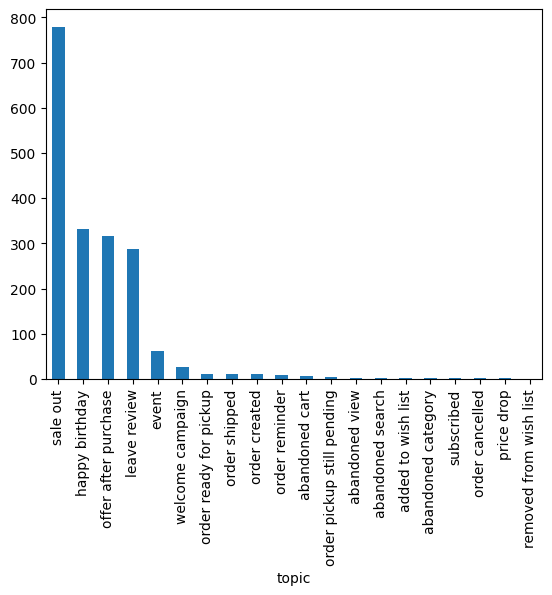

In [ ]:
df_campaigns['campaign_type'].value_counts().plot.bar()
plt.show()

df_campaigns['channel'].value_counts().plot.bar()
plt.show()

df_campaigns['topic'].value_counts().head(20).plot.bar()
plt.show()

## **campaign_type**

В нашем датасете преобладает bulk (т.е. массовая). Распределение сильно неравномерное

### **channel**

Говоря о каналах коммуникации, видим, что большая часть относится к mobile_push и email. sms и multichannel берут на себя очень маленькую часть

### **topic**

Распределение значения кампании (тема) так же сильно неравномерное. Очень много тем, которые встречаются по 1-10 раз. С другой стороны, тема sale out встречается аж 779 раз.


### Рассмотрим числовые признаки:

In [ ]:
num_cols = [
    'total_count',
    'subject_length'
]
df_campaigns[num_cols].describe()

,total_count,subject_length
count,1.824000e+03,1880.000000
mean,3.741295e+05,94.340426
std,8.198459e+05,28.482613
min,1.000000e+00,4.000000
25%,8.467500e+02,92.000000
50%,2.006500e+03,96.000000
75%,2.820332e+05,112.000000
max,5.371769e+06,185.000000


Для начала проверим на нормальность критерием Шапиро-Уилка:

In [ ]:
stats.shapiro(df_campaigns['total_count'].dropna())

ShapiroResult(statistic=np.float64(0.5251136581653486), pvalue=np.float64(7.708593064248773e-57))

In [ ]:
stats.shapiro(df_campaigns['subject_length'].dropna())

ShapiroResult(statistic=np.float64(0.7815101961616435), pvalue=np.float64(1.3386212327723765e-44))

pvalue в обоих случаях стремиться к нулю, что говорит нам о том, что распределение **сильно** не нормальное

### **total_count**

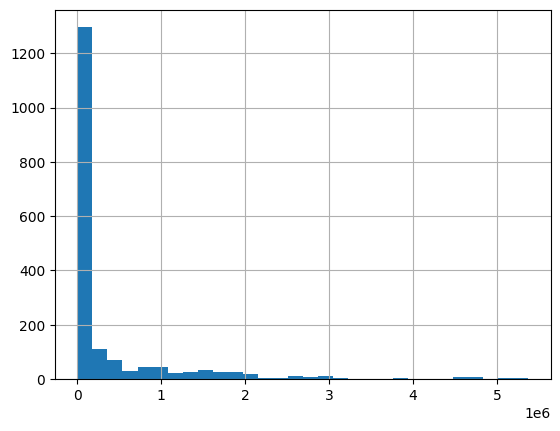

In [ ]:
df_campaigns['total_count'].dropna().hist(bins=30)
plt.show()

Видим, что большая часть кампаний имеют небольшое количество получателей, но так же есть и небольшое количество очень крупных кампаний, присутсвуют выбросы

In [ ]:
df_campaigns['total_count'].dropna().quantile([0.5, 0.9, 0.95, 0.99])

0.50       2006.50
0.90    1360510.10
0.95    1964064.35
0.99    4506894.76
Name: total_count, dtype: float64

<Axes: >

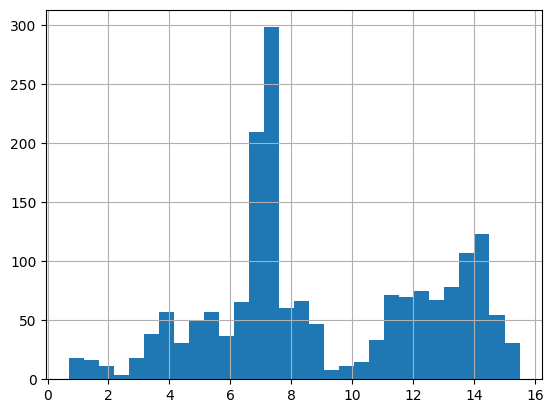

In [ ]:
np.log1p(df_campaigns['total_count']).dropna().hist(bins=30)

### **subject_length**

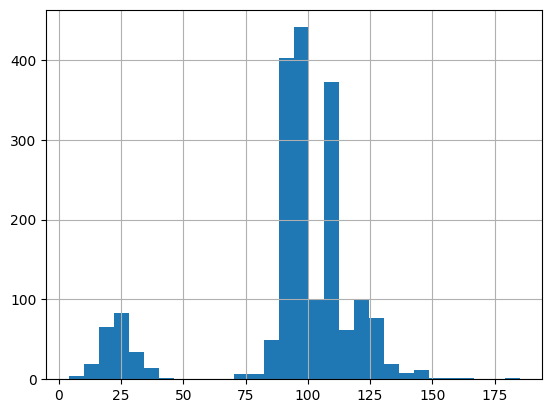

In [ ]:
df_campaigns['subject_length'].dropna().hist(bins=30)
plt.show()

Тут ситуация интереснее. Видим 2 локальных пика (в 25 и в 100), но это обосновано тем, что в нашем датасете преобладают mobile_push и email.



In [ ]:
df_campaigns.groupby('channel')['subject_length'].describe()

,count,mean,std,min,25%,50%,75%,max
channel,,,,,,,,
email,483.0,108.792961,16.100649,18.0,97.0,108.0,120.0,185.0
mobile_push,1396.0,89.402579,30.016169,4.0,92.0,96.0,112.0,164.0
multichannel,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sms,1.0,7.000000,NaN,7.0,7.0,7.0,7.0,7.0


### Рассмотрим временные признаки:

In [ ]:
df_campaigns['started_at'] = pd.to_datetime(df_campaigns['started_at'])
df_campaigns['finished_at'] = pd.to_datetime(df_campaigns['finished_at'])

# EDA 10-ти признаков **messages-demo.csv**

In [27]:
df_messages = pd.read_csv('../data/messages-demo.csv')


/var/folders/xj/7mygzp4528j3jxwc3l189znh0000gn/T/ipykernel_86364/3083508162.py:1: DtypeWarning: Columns (7,8,16,17,19,21,23,25,27,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df_messages = pd.read_csv('../data/messages-demo.csv')


In [ ]:
df = df_messages[['channel', 'message_type', 'platform', 'email_provider', 'stream', 'date', 'sent_at', 'is_opened', 'opened_first_time_at', 'opened_last_time_at']].copy()
df.head()

,channel,message_type,platform,email_provider,stream,date,sent_at,is_opened,opened_first_time_at,opened_last_time_at
0,email,transactional,NaN,mail.ru,desktop,2021-04-30,2021-04-30 11:27:43,t,2021-05-04 05:47:05,2021-05-04 05:47:05
1,email,transactional,NaN,yandex.ru,desktop,2021-04-30,2021-04-30 08:00:35,t,2021-05-04 15:38:20,2021-05-04 15:38:20
2,email,transactional,NaN,mail.ru,desktop,2021-04-30,2021-04-30 05:56:37,t,2021-05-04 15:16:32,2021-05-04 15:16:32
3,email,transactional,NaN,mail.ru,desktop,2021-04-30,2021-04-30 05:53:59,t,2021-05-04 09:47:25,2021-05-04 09:47:25
4,email,transactional,NaN,mail.ru,desktop,2021-04-30,2021-04-30 06:20:37,t,2021-05-04 18:56:16,2021-05-04 18:56:16


## channel - Канал, куда было отправлено сообщение. (категориальный)

email - обычное письмо на почту

mobile_push - пуш-уведомление в мобильном приложении

web_push - пуш-уведомление в браузер

In [59]:
print("Уникальных значений:", df['channel'].nunique(), end='\n\n')
print(df['channel'].value_counts(), end='\n\n')
print("Пропусков:", df['channel'].isna().sum())

Уникальных значений: 3

channel
email          5771209
mobile_push    4228525
web_push           266
Name: count, dtype: int64

Пропусков: 0


Text(0.5, 1.0, 'channel')

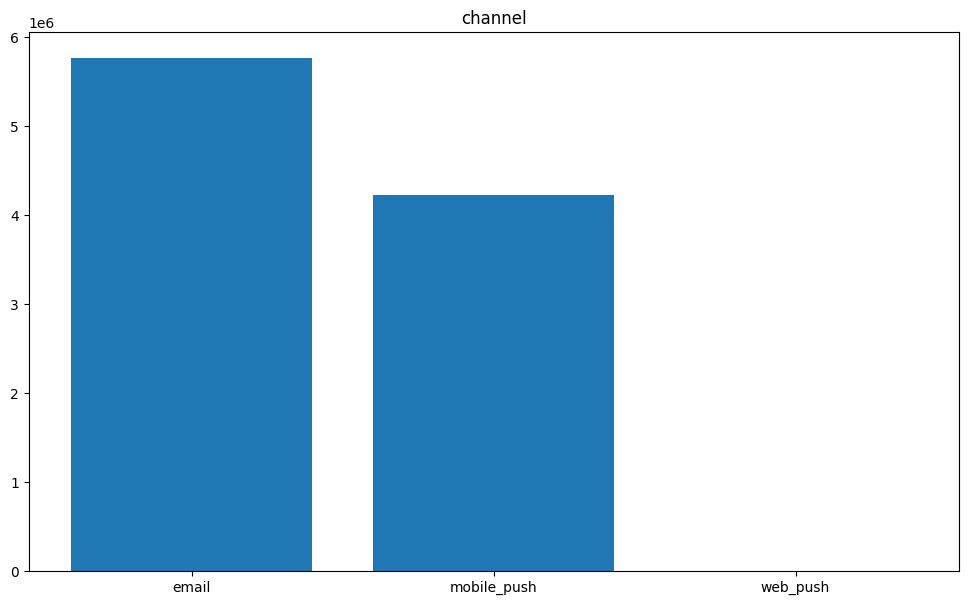

In [60]:
plt.figure(figsize=(12, 7))

table = df['channel'].value_counts()
plt.bar(table.index, table.values)
plt.title("channel")

## message_type - тип сообщения (Категориальный)

bulk - Массовая маркетинговая рассылка — акции, промо

trigger - Сообщение отправляемое автоматически после какого-то действия или события пользователя - напоминание о составленной корзине

transactional - Сообщение по операции пользователя — чек, подтверждение заказа, сброс пароля  

In [61]:
print("Уникальных значений:", df['message_type'].nunique(), end='\n\n')
print(df['message_type'].value_counts(), end='\n\n')
print("Пропусков:", df['message_type'].isna().sum())

Уникальных значений: 3

message_type
bulk             7062395
trigger          2138534
transactional     799071
Name: count, dtype: int64

Пропусков: 0


Text(0.5, 1.0, 'message_type')

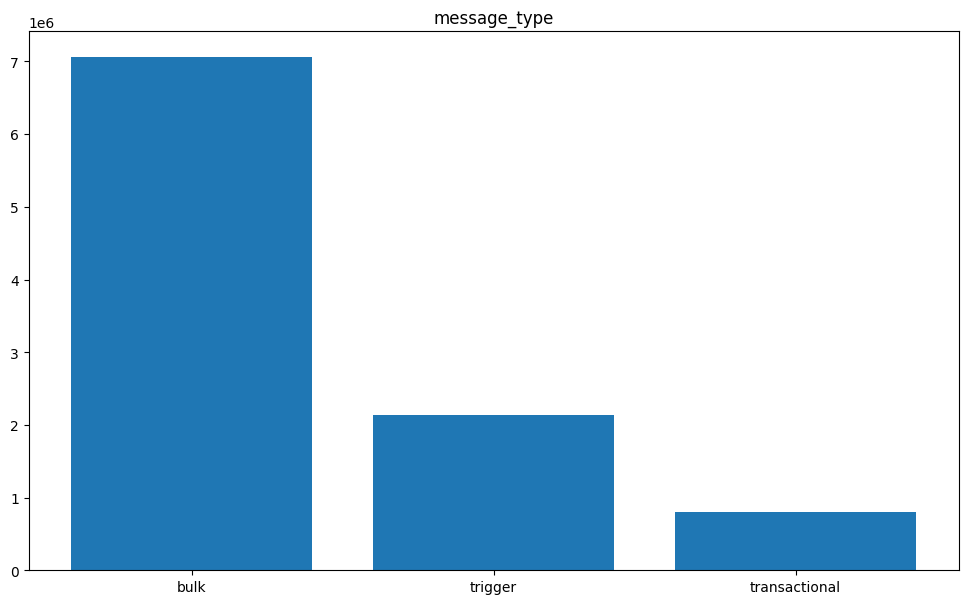

In [62]:
plt.figure(figsize=(12, 7))

counts = df['message_type'].value_counts()
plt.bar(counts.index, counts.values)
plt.title('message_type')

## platform - Тип платформы, на которой было открыто сообщение, если оно было открыто. (Категориальный)

desktop - ПК

smartphone - телефон

phablet - гибрид телефона и планшета

tablet - планшет

In [63]:
print("Уникальных значений:", df['platform'].nunique(), end='\n\n')
print(df['platform'].value_counts(), end='\n\n')
print("Пропусков:", df['platform'].isna().sum())

Уникальных значений: 4

platform
desktop       552380
smartphone    172704
phablet         6854
tablet          3785
Name: count, dtype: int64

Пропусков: 9264277


Text(0.5, 1.0, 'platform')

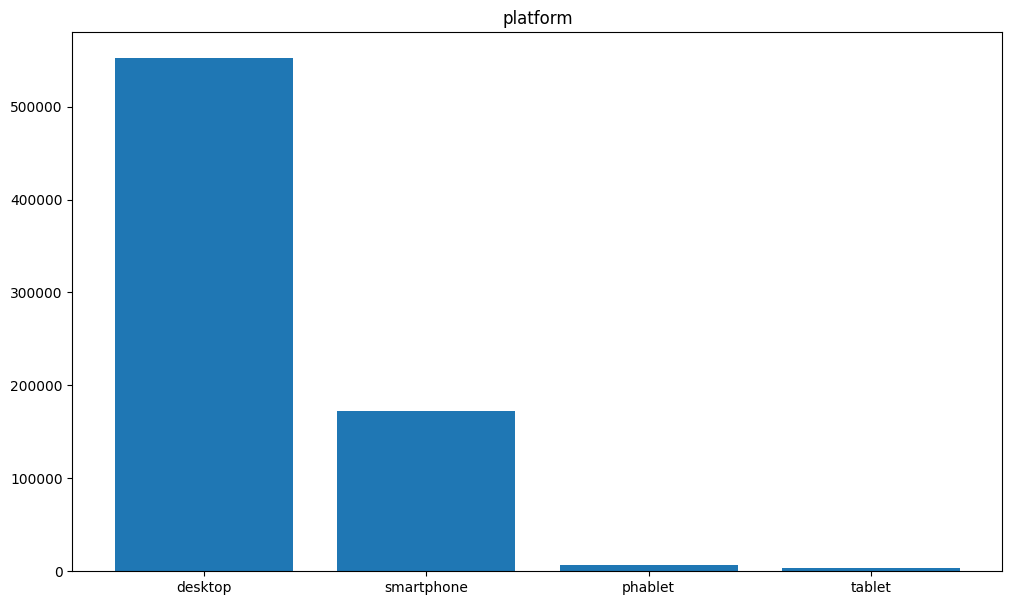

In [64]:
plt.figure(figsize=(12, 7))

table = df['platform'].value_counts()
plt.bar(table.index, table.values)
plt.title('platform')

## email_provider - почтовый домен, на который было отправлено сообщение. (Категориальный)

Может быть NA: данные удалены для уникальных персональных или корпоративных доменов с небольшим количеством сообщений, так как они могли бы привести к идентификации человека.

In [65]:
print("Уникальных значений:", df['email_provider'].nunique(), end='\n\n')
print(df['email_provider'].value_counts(), end='\n\n')
print("Пропусков:", df['email_provider'].isna().sum())

Уникальных значений: 205

email_provider
mail.ru             3175809
gmail.com            996947
yandex.ru            858487
bk.ru                257857
list.ru              149347
                     ...   
bashkortostan.ru          1
post.ru                   1
narfu.ru                  1
mailto.plus               1
rembler.ru                1
Name: count, Length: 205, dtype: int64

Пропусков: 4228693


Text(0.5, 1.0, 'Топ 15 самых популярных email_provider')

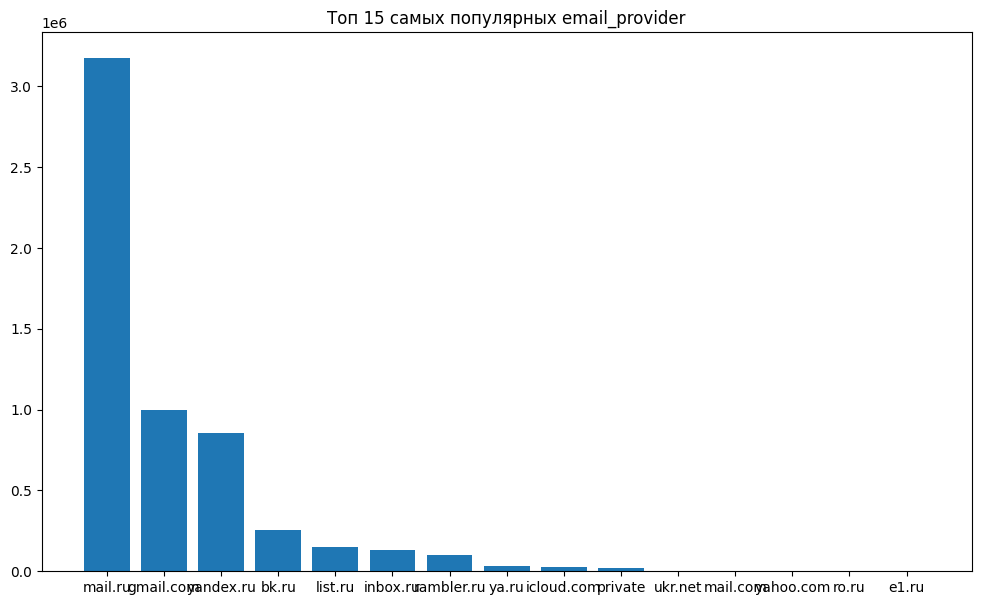

In [66]:
plt.figure(figsize=(12, 7))

table = df['email_provider'].value_counts().head(15)
plt.bar(table.index, table.values)
plt.title('Топ 15 самых популярных email_provider')

## stream - типа устройства, на котором было открыто сообщение, если оно было открыто. (Категориальный)

In [67]:
print("Уникальных значений:", df['stream'].nunique(), end='\n\n')
print(df['stream'].value_counts(), end='\n\n')
print("Пропусков:", df['stream'].isna().sum())

Уникальных значений: 1

stream
desktop    10000000
Name: count, dtype: int64

Пропусков: 0


В нашей выборке из 10 млн объектов, у stream всего одно уникальное значение, следовательно можно дропнуть (Но в полном датасете на 720 млн строк больше уникальных значений)

## date - дата в YYYY-MM-DD сообщение было отправлено (Временной признак)

In [68]:
df['date'] = pd.to_datetime(df['date'])
print("Уникальных значений:", df['date'].nunique(), end='\n\n')
print("Пропусков:", df['date'].isna().sum())

Уникальных значений: 46

Пропусков: 0


In [69]:
date_sorted = df['date'].sort_values()
date_sorted = date_sorted.dt.strftime('%Y-%m-%d')
print("Начало рассматриваемого периода:", date_sorted.iloc[0])
print("Конец периода:", date_sorted.iloc[-1])

Начало рассматриваемого периода: 2021-04-30
Конец периода: 2021-06-14


## sent_at - дата и время когда было отправленно сообщение (Временной признак)

In [70]:
df['sent_at'] = pd.to_datetime(df['sent_at'])
print("Уникальных значений:", df['sent_at'].nunique(), end='\n\n')
print("Пропусков:", df['sent_at'].isna().sum())

Уникальных значений: 1132623

Пропусков: 0


## is_opened - Было ли открыто сообщение (Бинарный)

t - было открыто

f - не было открыто

In [71]:
print("Уникальных значений:", df['is_opened'].nunique(), end='\n\n')
print(df['is_opened'].value_counts(), end='\n\n')
print("Пропусков:", df['is_opened'].isna().sum())

Уникальных значений: 2

is_opened
f    8386293
t    1613707
Name: count, dtype: int64

Пропусков: 0


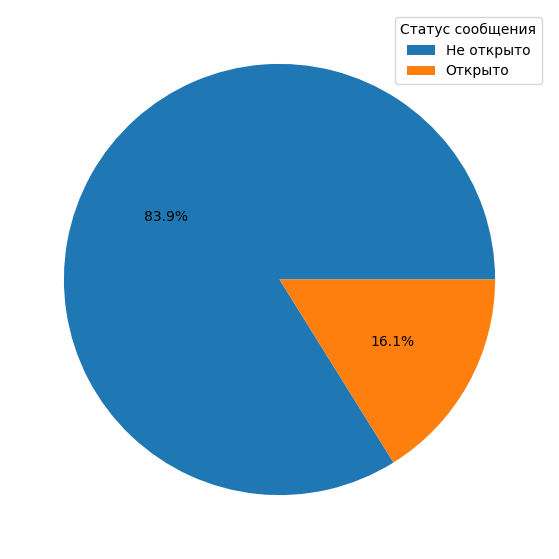

In [72]:
plt.figure(figsize=(12, 7))

table = df['is_opened'].value_counts()
plt.pie(table.values, autopct='%1.1f%%')

labels = {'f': 'Не открыто', 't': 'Открыто'}
plt.legend(labels=[labels[x] for x in table.index], title='Статус сообщения',)

## opened_first_time_at - дата и время когда сообщение впервые открыли (временной признак)

In [73]:
df['opened_first_time_at'] = pd.to_datetime(df['opened_first_time_at'])
print("Уникальных значений:", df['opened_first_time_at'].nunique(), end='\n\n')
print("Пропусков:", df['opened_first_time_at'].isna().sum())

Уникальных значений: 845489

Пропусков: 8386293


## opened_last_time_at - дата и время, когда сообщение открыли в последний раз (временной признак)

Если сообщение открыли только 1 раз, то opened_first_time_at и opened_last_time_at будут совпадать

In [74]:
df['opened_last_time_at'] = pd.to_datetime(df['opened_last_time_at'])
print("Уникальных значений:", df['opened_last_time_at'].nunique(), end='\n\n')
print("Пропусков:", df['opened_last_time_at'].isna().sum())

Уникальных значений: 867537

Пропусков: 8386293


In [75]:
df['sent_open_time'] = df['opened_first_time_at'] - df['sent_at']
df.sample(10)

,channel,message_type,platform,email_provider,stream,date,sent_at,is_opened,opened_first_time_at,opened_last_time_at,sent_open_time
8070557,email,transactional,NaN,rambler.ru,desktop,2021-05-29,2021-05-29 17:57:38,t,2021-05-29 17:59:45,2021-05-29 17:59:45,0 days 00:02:07
4335319,email,trigger,NaN,gmail.com,desktop,2021-05-16,2021-05-16 20:35:30,f,NaT,NaT,NaT
969855,mobile_push,bulk,NaN,NaN,desktop,2021-04-30,2021-04-30 08:21:40,f,NaT,NaT,NaT
4782,email,transactional,NaN,mail.ru,desktop,2021-04-30,2021-04-30 12:15:19,t,2021-04-30 13:49:19,2021-04-30 13:49:19,0 days 01:34:00
8974697,mobile_push,bulk,NaN,NaN,desktop,2021-06-04,2021-06-04 12:00:18,f,NaT,NaT,NaT
393449,mobile_push,bulk,NaN,NaN,desktop,2021-04-30,2021-04-30 07:40:47,f,NaT,NaT,NaT
8567620,email,trigger,NaN,ya.ru,desktop,2021-06-03,2021-06-03 10:05:08,f,NaT,NaT,NaT
8905947,email,transactional,NaN,list.ru,desktop,2021-06-04,2021-06-04 05:40:08,f,NaT,NaT,NaT
9226946,email,trigger,desktop,bk.ru,desktop,2021-06-07,2021-06-07 06:14:00,t,2021-06-07 11:42:30,2021-06-07 11:42:30,0 days 05:28:30
6684082,email,bulk,NaN,mail.ru,desktop,2021-05-24,2021-05-24 07:52:10,f,NaT,NaT,NaT


# Продолжение EDA по messages

# Is_clicked - нажато ли на сообщение(бинарный) - скорее всего важный

In [51]:
df_messages['is_clicked'].value_counts()

is_clicked
f    9764649
t     235351
Name: count, dtype: int64

In [52]:
def bin_code_is_clicked(x):
    return 1 if x == 't' else 0

df_messages['is_clicked'] = df_messages['is_clicked'].apply(lambda x: bin_code_is_clicked(x))

df_messages['is_clicked'].value_counts()

is_clicked
0    9764649
1     235351
Name: count, dtype: int64

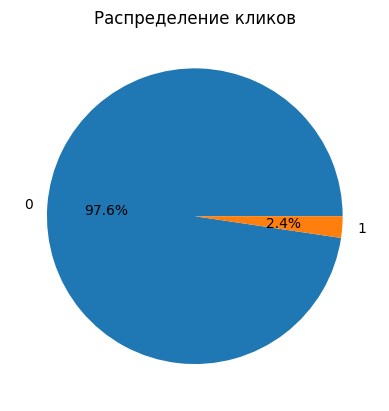

In [6]:
counts = df_messages['is_clicked'].value_counts()
plt.pie(counts, labels = counts.index, autopct= '%1.1f%%')

plt.title('Распределение кликов')

plt.show()

большой дисбаланс классов, что свойственно рекламе

# clicked_first_time_at - когда в первый раз было кликнуто(дата)

согласованность данных: nan-ы только там, где is_clicked == 0

In [7]:
9764649 == df_messages[df_messages['is_clicked'] == 0]['clicked_first_time_at'].isna().sum()

np.True_

кандидат на удаление

# clicked_last_time_at - когда последний раз было кликнуто(дата)

согласованность данных: nan-ы только там, где is_clicked == 0

In [8]:
9764649 == df_messages[df_messages['is_clicked'] == 0]['clicked_last_time_at'].isna().sum()

np.True_

аналогично кандидат на удаление

# is_unsubscribed - отписался ли от рассылки после того, как пришло уведомление(бинарный)

In [9]:
df_messages['is_unsubscribed'].value_counts()

is_unsubscribed
f    9696821
t     303179
Name: count, dtype: int64

In [53]:
def bin_code_is_unsubscribed(x):
    return 1 if x == 't' else 0

df_messages['is_unsubscribed'] = df_messages['is_unsubscribed'].apply(lambda x: bin_code_is_unsubscribed(x))

df_messages['is_unsubscribed'].value_counts()

is_unsubscribed
0    9696821
1     303179
Name: count, dtype: int64

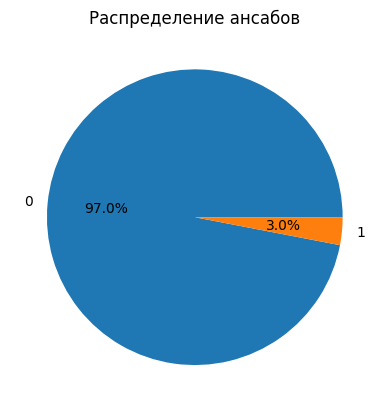

In [11]:
counts = df_messages['is_unsubscribed'].value_counts()
plt.pie(counts, labels = counts.index, autopct= '%1.1f%%')

plt.title('Распределение ансабов')

plt.show()

In [12]:
df_messages[df_messages['is_unsubscribed'] == 1]['is_purchased'].value_counts()

is_purchased
f    303159
t        20
Name: count, dtype: int64

есть те, кто отписался от рассылки, но при этом приобрел

# unsubscribed_at - когда отписался(дата)

In [13]:
df_messages['unsubscribed_at'].value_counts()

unsubscribed_at
2021-04-30 08:30:02    1038
2021-04-30 08:29:57     972
2021-04-30 08:29:58     961
2021-04-30 08:30:01     950
2021-04-30 08:29:59     950
                       ... 
2021-05-21 07:28:26       1
2021-05-21 07:03:06       1
2021-05-21 05:55:57       1
2021-05-26 06:54:53       1
2021-06-14 16:42:06       1
Name: count, Length: 28103, dtype: int64

In [14]:
9696821 == df_messages[df_messages['is_unsubscribed'] == 0]['unsubscribed_at'].isna().sum()

np.True_

кандидат на удаление

# is_hard_bounced - жесткий отказ при отправке сообщения(ошибка), который невозможно исправить автоматически

In [15]:
df_messages['is_hard_bounced'].value_counts()

is_hard_bounced
f    9968883
t      31117
Name: count, dtype: int64

In [54]:
def bin_code_is_hard_bounced(x):
    return 1 if x == 't' else 0

df_messages['is_hard_bounced'] = df_messages['is_hard_bounced'].apply(lambda x: bin_code_is_hard_bounced(x))

df_messages['is_hard_bounced'].value_counts()

is_hard_bounced
0    9968883
1      31117
Name: count, dtype: int64

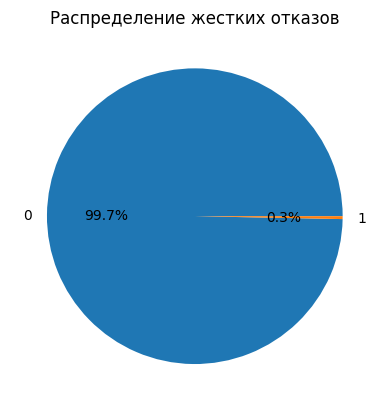

In [17]:
counts = df_messages['is_hard_bounced'].value_counts()
plt.pie(counts, labels = counts.index, autopct= '%1.1f%%')

plt.title('Распределение жестких отказов')

plt.show()

# hard_bounced_at - дата жесткого отказа

In [18]:
df_messages['hard_bounced_at'].value_counts()

hard_bounced_at
2021-05-27 05:50:31    7
2021-05-22 09:50:40    7
2021-06-03 05:50:27    7
2021-06-03 05:50:33    7
2021-05-21 05:25:36    7
                      ..
2021-05-15 12:25:05    1
2021-05-15 12:25:10    1
2021-05-15 12:50:06    1
2021-05-15 13:25:05    1
2021-06-14 13:25:05    1
Name: count, Length: 8176, dtype: int64

согласованность:

In [19]:
9968883 == df_messages[df_messages['is_hard_bounced'] == 0]['hard_bounced_at'].isna().sum()

np.True_

кандидат на удаление

# is_soft_bounced - мягкий отказ(сообщение не дошло, но может дойти позже). Например, у получателя фуловая почта, временный сбой на сервере

In [20]:
df_messages['is_soft_bounced'].value_counts()

is_soft_bounced
f    9995560
t       4440
Name: count, dtype: int64

In [55]:
def bin_code_is_soft_bounced(x):
    return 1 if x == 't' else 0

df_messages['is_soft_bounced'] = df_messages['is_soft_bounced'].apply(lambda x: bin_code_is_soft_bounced(x))

df_messages['is_soft_bounced'].value_counts()

is_soft_bounced
0    9995560
1       4440
Name: count, dtype: int64

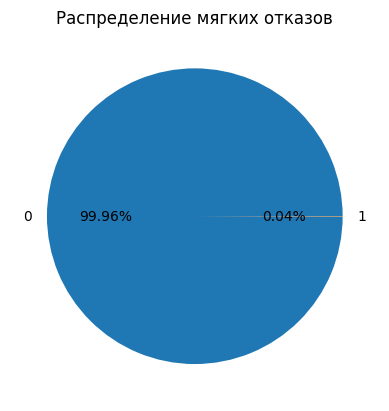

In [22]:
counts = df_messages['is_soft_bounced'].value_counts()
plt.pie(counts, labels = counts.index, autopct= '%1.2f%%')

plt.title('Распределение мягких отказов')

plt.show()

# soft_bounced_at - когда был мягкий отказ

In [23]:
df_messages['soft_bounced_at'].value_counts()

soft_bounced_at
2021-05-22 15:27:27    7
2021-05-22 15:25:29    7
2021-05-22 15:26:13    7
2021-05-22 15:25:47    7
2021-05-22 15:28:59    7
                      ..
2021-05-19 01:50:04    1
2021-05-18 23:50:05    1
2021-05-18 20:50:07    1
2021-05-18 16:50:05    1
2021-06-14 21:50:05    1
Name: count, Length: 1830, dtype: int64

согласованность: 

In [24]:
9995560 == df_messages[df_messages['is_soft_bounced'] == 0]['soft_bounced_at'].isna().sum()

np.True_

# Продолжение EDA по другим признакам:

In [28]:
my_df = df_messages[['is_complained', 'complained_at', 'is_blocked', 'blocked_at', 'is_purchased', 'purchased_at', 'created_at', 'updated_at']]
my_df.head()

,is_complained,complained_at,is_blocked,blocked_at,is_purchased,purchased_at,created_at,updated_at
0,f,NaN,f,NaN,t,2021-05-06 16:40:38,2023-04-27 08:55:05.883908,2023-04-27 08:57:33.080129
1,f,NaN,f,NaN,f,NaN,2023-04-27 08:55:06.265821,2023-04-27 08:56:18.60223
2,f,NaN,f,NaN,f,NaN,2023-04-27 08:55:06.777039,2023-04-27 08:56:19.112546
3,f,NaN,f,NaN,f,NaN,2023-04-27 08:55:07.325906,2023-04-27 08:56:19.590637
4,f,NaN,f,NaN,f,NaN,2023-04-27 08:55:07.727792,2023-04-27 08:56:19.926474


Смотрим пропуски по признакам

In [29]:
my_df.isna().sum()

is_complained          0
complained_at    9995135
is_blocked             0
blocked_at       9999781
is_purchased           0
purchased_at     9987660
created_at             0
updated_at             0
dtype: int64

# Признак `is_blocked` и `blocked_at`

Отражает было ли заблокировано письмо при отправке почтовым сервисом клиента, чтобы предотвратить возможную спам рассылку, если же письмо было заблокировано, то `blocked_at` показывает когда это было сделано

In [30]:
my_df['is_blocked'].value_counts()

is_blocked
f    9999781
t        219
Name: count, dtype: int64

In [31]:
blocks = pd.DataFrame(my_df['blocked_at'].value_counts().reset_index())
blocks

,blocked_at,count
0,2021-05-24 08:50:10,5
1,2021-05-24 08:50:06,5
2,2021-05-24 08:50:08,5
3,2021-05-24 08:50:09,5
4,2021-05-24 08:50:07,4
...,...,...
189,2021-05-22 08:36:20,1
190,2021-05-22 08:27:20,1
191,2021-05-22 14:35:20,1
192,2021-05-22 18:28:34,1


In [32]:
blocks = pd.to_datetime(my_df['blocked_at']).dt.date.value_counts().reset_index()
blocks = blocks.sort_values(by='blocked_at')
blocks

,blocked_at,count
8,2021-05-02,1
4,2021-05-04,5
2,2021-05-05,11
9,2021-05-19,1
6,2021-05-20,2
3,2021-05-21,7
0,2021-05-22,153
1,2021-05-24,31
10,2021-05-26,1
5,2021-05-27,3


# График отражающий кол-во таких блокировок по дням

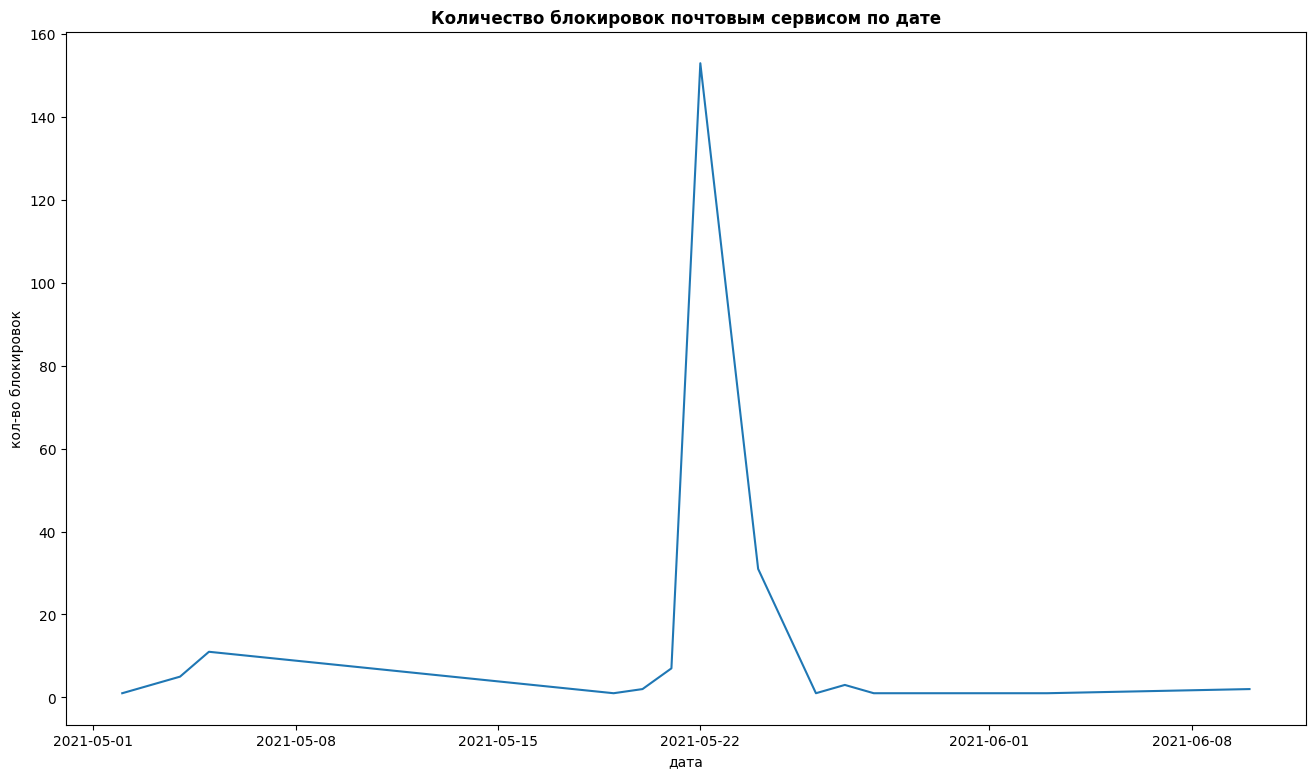

In [33]:
plt.figure(figsize=(16, 9))
sns.lineplot(data=blocks, x='blocked_at', y='count')
plt.xlabel('дата')
plt.ylabel('кол-во блокировок')
plt.title('Количество блокировок почтовым сервисом по дате', fontweight='bold')
plt.show()

# Признак `	is_complained` и `complained_at`

Признак отражает `is_complained` нажал ли получатель кнопку SPAM в своём почтовом сервисе, и если нажал то когда (`complained_at`) 

In [34]:
my_df['is_complained'].value_counts()

is_complained
f    9995135
t       4865
Name: count, dtype: int64

In [35]:
complain = pd.DataFrame(my_df['complained_at'].value_counts().reset_index())
complain = pd.to_datetime(complain['complained_at']).dt.date.value_counts().reset_index()
complain = complain.sort_values(by='complained_at')
complain

,complained_at,count
27,2021-04-30,30
56,2021-05-01,14
60,2021-05-02,12
32,2021-05-03,26
24,2021-05-04,31
...,...,...
113,2021-12-15,2
138,2022-01-02,1
119,2022-01-11,2
98,2022-01-14,3


# График отражающий кол-во меток спама по дням

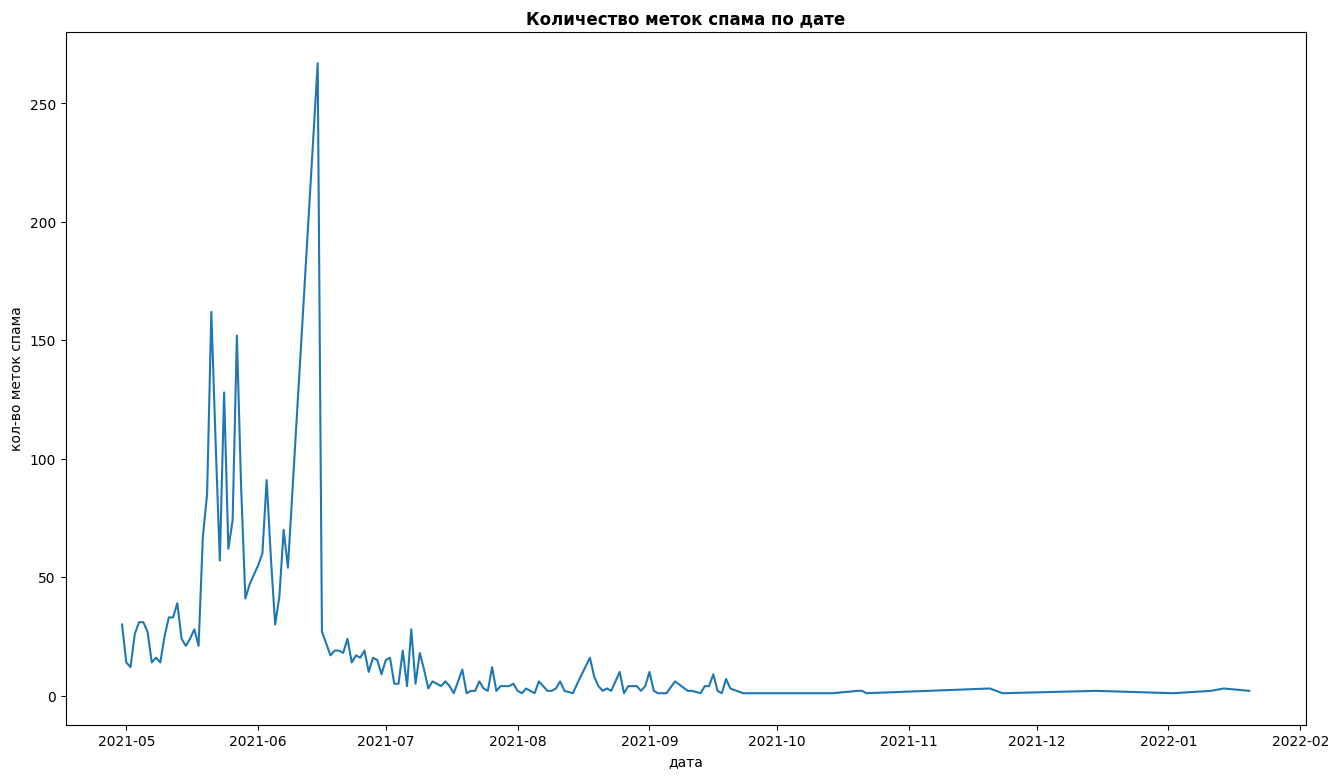

In [36]:
plt.figure(figsize=(16, 9))
sns.lineplot(data=complain, x='complained_at', y='count')
plt.xlabel('дата')
plt.ylabel('кол-во меток спама')
plt.title('Количество меток спама по дате', fontweight='bold')
plt.show()

# Признак `is_purchased` и `purchased_at`

Признак `is_purchased` отражает перешёл ли получатель письма по ссылке на сайт или приложение и сделал покупку у компании, и если сделал, то когда(`purchased_at`)

In [37]:
my_df['is_purchased'].value_counts()

is_purchased
f    9987660
t      12340
Name: count, dtype: int64

In [38]:
purchase = pd.DataFrame(my_df['purchased_at'].value_counts().reset_index())
purchase

,purchased_at,count
0,2021-05-22 07:29:43,11
1,2021-05-22 07:29:41,9
2,2021-05-22 07:28:39,9
3,2021-05-22 07:29:54,9
4,2021-05-22 07:29:46,9
...,...,...
11968,2021-05-22 09:35:11,1
11969,2021-05-20 10:07:09,1
11970,2021-05-23 11:24:42,1
11971,2021-05-19 10:24:44,1


In [39]:
purchase = pd.to_datetime(purchase['purchased_at']).dt.date.value_counts().reset_index()
purchase = purchase.sort_values(by='purchased_at')
purchase

,purchased_at,count
33,2021-04-30,186
39,2021-05-01,159
37,2021-05-02,163
36,2021-05-03,164
35,2021-05-04,167
...,...,...
86,2021-10-14,1
79,2021-10-20,1
101,2021-10-21,1
91,2021-11-11,1


# График отражающий кол-во покупок клиентов по дням

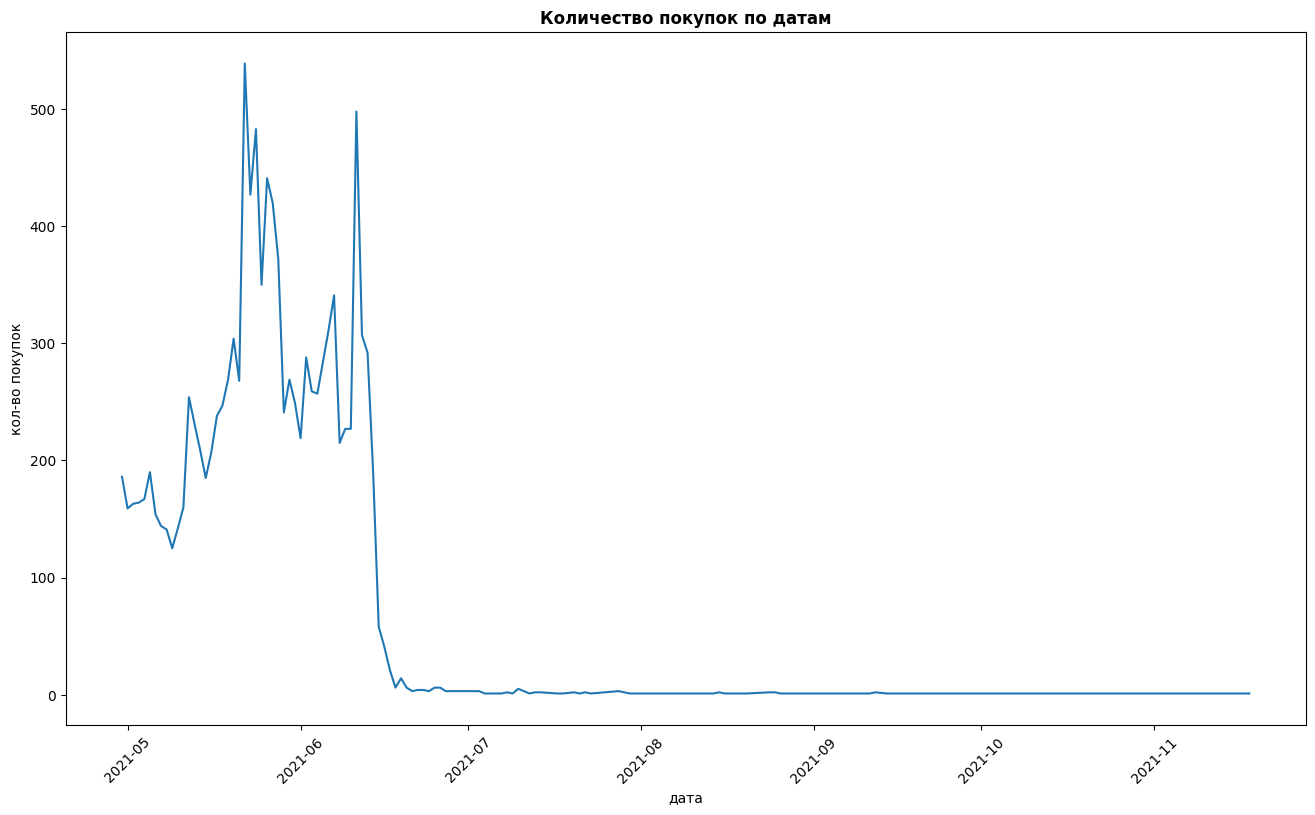

In [40]:
plt.figure(figsize=(16, 9))
sns.lineplot(data=purchase, x='purchased_at', y='count')
plt.xlabel('дата')
plt.ylabel('кол-во покупок')
plt.title('Количество покупок по датам', fontweight='bold')
plt.xticks(rotation=45)
plt.show()

# Совместный график отражающий количетсво меток спама и количество покупок по датам

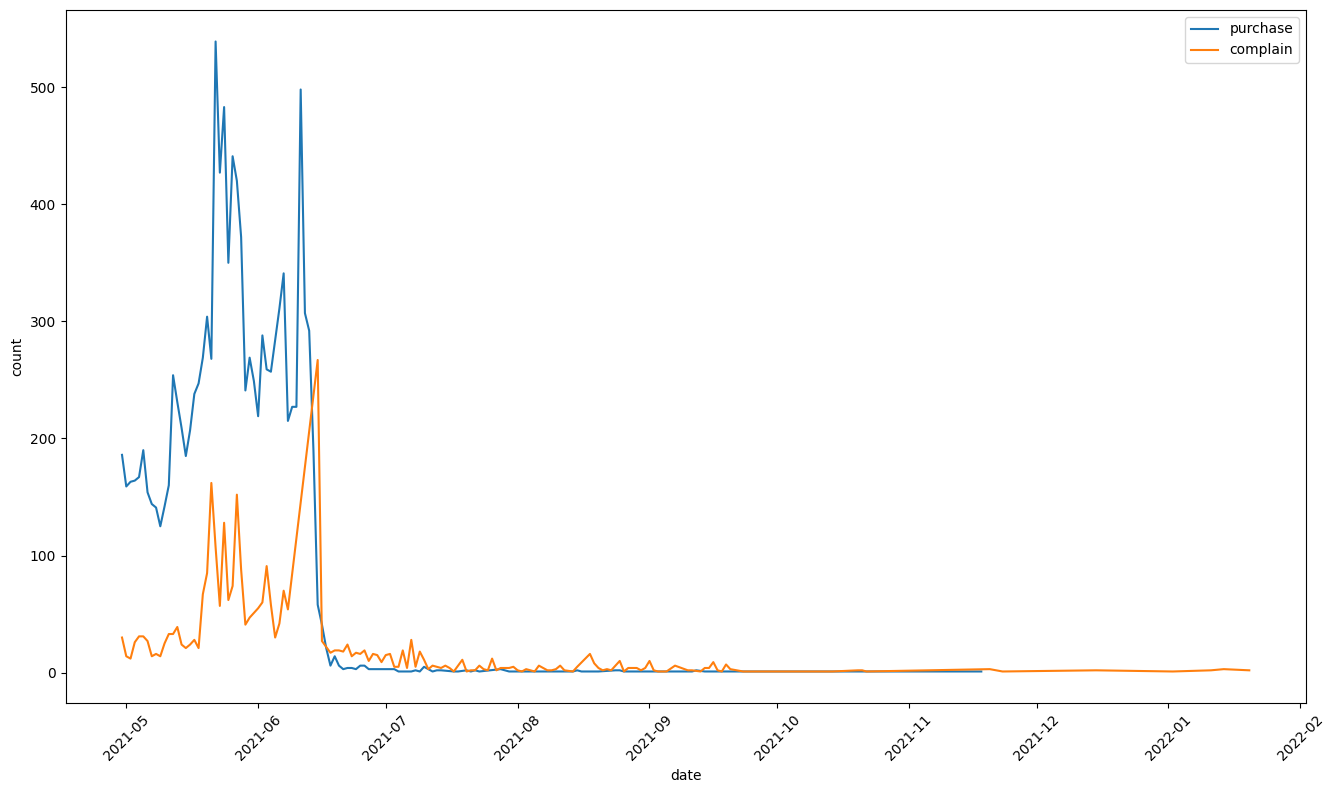

In [41]:
plt.figure(figsize=(16, 9))
sns.lineplot(data=purchase, x='purchased_at', y='count', label='purchase')
sns.lineplot(data=complain, x='complained_at', y='count', label='complain')
plt.legend()
plt.xlabel('date')
plt.xticks(rotation=45)
plt.show()

# Совместный график со всеми событиями и по датам

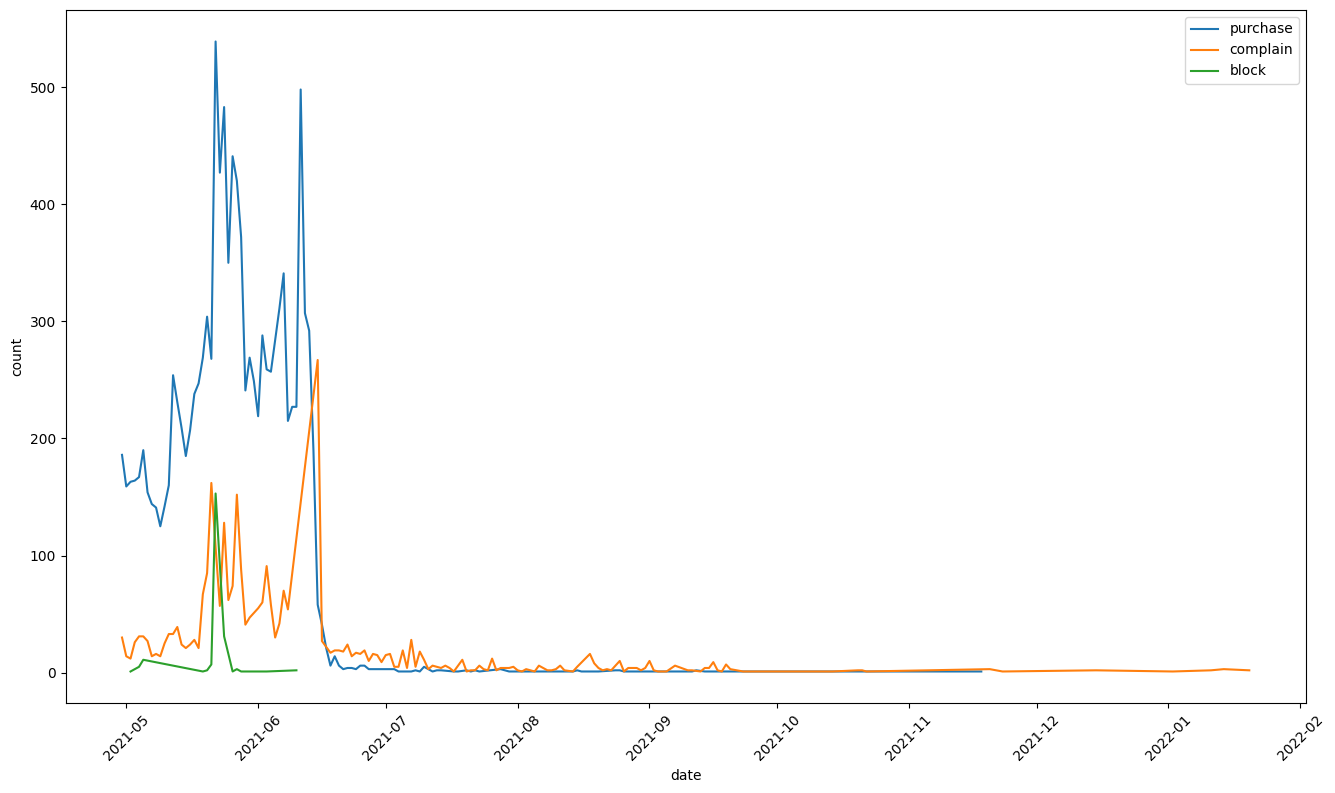

In [42]:
plt.figure(figsize=(16, 9))
sns.lineplot(data=purchase, x='purchased_at', y='count', label='purchase')
sns.lineplot(data=complain, x='complained_at', y='count', label='complain')
sns.lineplot(data=blocks, x='blocked_at', y='count', label='block')
plt.legend()
plt.xlabel('date')
plt.xticks(rotation=45)
plt.show()

# Multivariate analysis

Все признаки с окончанием `.._at` были дропнуты, тк они имеют прямуб корреляцию с признаками формата `is_..`, к тому же они имеют формат datetime, что не подходит для задач регрессии или классификации. Признаки `created_at` и `updated_at` отражают внутренние обновления для каждого письма и никак не влияют на факт купит ли клиент или нет.

In [43]:
my_df_new = my_df.drop(['created_at', 'updated_at', 'complained_at', 'blocked_at', 'purchased_at'], axis=1)
my_df_new

,is_complained,is_blocked,is_purchased
0,f,f,t
1,f,f,f
2,f,f,f
3,f,f,f
4,f,f,f
...,...,...,...
9999995,f,f,f
9999996,f,f,f
9999997,f,f,f
9999998,f,f,f


In [44]:
encoder = LabelEncoder()
for l in ['is_complained', 'is_blocked', 'is_purchased']:
    my_df_new[l] = encoder.fit_transform(my_df_new[l])
my_df_new

,is_complained,is_blocked,is_purchased
0,0,0,1
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0
...,...,...,...
9999995,0,0,0
9999996,0,0,0
9999997,0,0,0
9999998,0,0,0


для признаков:
is_clicked, clicked_first_time_at, clicked_last_time_at, is_unsubscribed, unsubscribed_at, is_hard_bounced, hard_bounced_at, is_soft_bounced, soft_bounced_at

связь с целевой переменной is_purchased

is_clicked:

In [56]:
df_messages[df_messages['is_clicked'] == 0]['is_purchased'].value_counts()

is_purchased
f    9764649
Name: count, dtype: int64

несогласованности нет. Если на уведомление не нажато, то покупки нет

is_unsubcribed:

In [57]:
df_messages[df_messages['is_unsubscribed'] == 1]['is_purchased'].value_counts()

is_purchased
f    303159
t        20
Name: count, dtype: int64

а тут уже ситуация интересная. Если от рассылки отписались, то покупка может быть совершена, но всего в 20 случаях. Значит признак небесполезный, а просто сильно влияющий на отрицательный исход

is_hard_bounced:

In [58]:
df_messages[df_messages['is_hard_bounced'] == 1]['is_purchased'].value_counts()

is_purchased
f    31117
Name: count, dtype: int64

если тяжелый отказ, то всегда покупка не будет завершена

is_soft_bounced:

In [59]:
df_messages[df_messages['is_soft_bounced'] == 1]['is_purchased'].value_counts()

is_purchased
f    4440
Name: count, dtype: int64

если был мягкий отказ, то покупка все равно не была совершена

# Вывод по мультивариативному анализу:
все признаки, кроме is_unsubscribed неинформативны для машинного обучения

..............

# Feature encoding + Future Engineering function

In [ ]:
def feature_encoding_and_Future_Engineering():
    #целевая переменная
    def bin_code_purchase(x):
        return 1 if x == 't' else 0

    df_messages['is_purchased'] = df_messages['is_purchased'].apply(lambda x: bin_code_purchase(x))

    #is_unsubscribed
    def bin_code_is_unsubscribed(x):
        return 1 if x == 't' else 0

    df_messages['is_unsubscribed'] = df_messages['is_unsubscribed'].apply(lambda x: bin_code_is_unsubscribed(x))